## ⭐️ Mohammad Amin Heidary

## IMPORT REQUIRED LIBRARIES 📚

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.svm import SVC
import joblib

pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = None

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

---

## Load dataset 💽

In [3]:
try:
   df = pd.read_csv("data/used_cars.csv")
   print('- Data loaded ✅')
except:
    print('- Error data loading ❌')

- Data loaded ✅


---

In [4]:
print(f"\n📈 Dataset shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")


📈 Dataset shape: (4009, 12)
📋 Columns: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


In [5]:
print('===== First 5 row =====')
df.head()

===== First 5 row =====


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300.00"
1,Chevrolet,S-10 LS,2000,"133,510 mi.",E85 Flex Fuel,120.0HP 2.2L 4 Cylinder Engine Flex Fuel Capability,A/T,Blue,Black,None reported,Yes,"$4,500.00"
2,Audi,Q5 2.0T Premium Plus,2017,"81,880 mi.",E85 Flex Fuel,2.0L I4 16V GDI DOHC Turbo Flexible Fuel,8-Speed Automatic,Mythos Black Metallic,Black,None reported,Yes,"$21,375.00"
3,Bentley,Continental GTC Base,2011,"20,200 mi.",E85 Flex Fuel,552.0HP 6.0L 12 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,None reported,Yes,"$79,950.00"
4,Ford,Utility Police Interceptor Base,2013,"105,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,A/T,White,Black,At least 1 accident or damage reported,Yes,"$6,600.00"


In [6]:
print('===== last 5 row =====')
df.tail(5)

===== last 5 row =====


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Tesla,Model Y Long Range,2021,"49,252 mi.",NaN,Electric,1-Speed Automatic,Deep Blue Metallic,Black,None reported,NaN,"$37,999.00"
4005,Tesla,Model S 100D,2018,"65,000 mi.",NaN,518.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,"$41,000.00"
4006,Tesla,Model X Performance,2020,"25,535 mi.",NaN,778.0HP Electric Motor Electric Fuel System,A/T,White,Beige,None reported,Yes,"$68,969.00"
4007,Tesla,Model 3 Long Range,2021,"23,749 mi.",NaN,Electric,1-Speed Automatic,White,Black,None reported,NaN,"$35,999.00"
4008,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998.00"


In [7]:
print("📊 DATASET INFORMATION:")
print("="*40)
df.info()

📊 DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [8]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [9]:
df['price'] = (df['price'].str.replace('$', '', regex=False).str.replace(',', '',regex=False).astype(float))
print(df['price'].head())
print(f'Min: {df['price'].min()} | Max: {df['price'].max()}')

0    10300.0
1     4500.0
2    21375.0
3    79950.0
4     6600.0
Name: price, dtype: float64
Min: 2000.0 | Max: 2954083.0


In [10]:
df['milage'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex= False).astype('Int64')
print(df['milage'].head())
print(f'Min: {df['milage'].min()} | Max: {df['milage'].max()}')

0     51000
1    133510
2     81880
3     20200
4    105000
Name: milage, dtype: Int64
Min: 100 | Max: 405000


In [11]:
df['car_age'] = date.today().year - df['model_year']
pd.DataFrame({
    'Model Year' : df['model_year'],
    'Car Age': df['car_age']
}).sample(5)

,Model Year,Car Age
724,2015,11
2509,2017,9
2225,2018,8
3546,2020,6
1219,2013,13


---

## Filling NaN values ✅

In [12]:
df = df.replace('–', np.nan)

In [13]:
missing_data = df.isnull().sum()
missing_percent_rep = (missing_data / len(df)) * 100
missing_value = pd.DataFrame({
    'Missing Data': missing_data,
    'Missing Percent': round(missing_percent_rep,2)
})
print('❌ Missing value:')
print('='*40)
missing_value

❌ Missing value:


,Missing Data,Missing Percent
brand,0,0.00
model,0,0.00
model_year,0,0.00
milage,0,0.00
fuel_type,215,5.36
engine,45,1.12
transmission,4,0.10
ext_col,15,0.37
int_col,133,3.32
accident,113,2.82


* ### Filling fuel type, accident, clean title ✔️

In [14]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna('None reported')
df['clean_title'] = df['clean_title'].fillna('Unknown')
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine           45
transmission      4
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling engine ✔️

In [15]:
initial_rows = len(df)
# first stage
df['engine'] = df['engine'].fillna(df.groupby(['brand', 'model'])['engine'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# second stage
df['engine'] = df['engine'].fillna(df.groupby('brand')['engine'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# third stage
df = df.dropna(subset=['engine'])

removed_rows = initial_rows - len(df)

print(f"✓ Grouped engine cleaning completed.")
print(f"✓ Number of cars completely removed in the third layer: {removed_rows} rows")
print(f"✓ Number of remaining data points in the dataset: {len(df)} \n")
print('=====isnull=====')
df.isnull().sum()

✓ Grouped engine cleaning completed.
✓ Number of cars completely removed in the third layer: 0 rows
✓ Number of remaining data points in the dataset: 4009 

=====isnull=====


brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      4
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling transmission ✔️

In [16]:
df[df['transmission'].isna()]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
588,Porsche,911 Carrera S,2017,16701,Gasoline,3.0 Liter,NaN,Red,NaN,None reported,Unknown,107998.0,9
903,Porsche,911 Carrera 4S,2018,31678,Gasoline,3.0 Liter,NaN,Silver,NaN,None reported,Unknown,106798.0,8
3797,Ford,Bronco,1974,6217,Gasoline,2.7L V6 24V PDI DOHC Twin Turbo,NaN,Dark Gray Metallic,NaN,None reported,Yes,115000.0,52
3808,Rolls-Royce,Phantom,2023,1560,Gasoline,6.8L V12 48V GDI DOHC Twin Turbo,NaN,Tempest,Cobalt Blue,None reported,Yes,599995.0,3


In [17]:
initial_rows_trans = len(df)
# first stage
df['transmission'] = df['transmission'].fillna(
    df.groupby(['brand', 'model', 'engine'])['transmission'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# second stage
df['transmission'] = df['transmission'].fillna(
    df.groupby(['brand', 'model'])['transmission'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

# third stage
df = df.dropna(subset=['transmission'])

removed_rows_trans = initial_rows_trans - len(df)

print(f"✓ Cascading transmission cleaning completed successfully.")
print(f"✓ Number of cars removed in the final layer: {removed_rows_trans} rows")
print(f"✓ Number of remaining data points in the entire dataset: {len(df)} \n")
print('=====isnull=====')
df.isnull().sum()

✓ Cascading transmission cleaning completed successfully.
✓ Number of cars removed in the final layer: 0 rows
✓ Number of remaining data points in the entire dataset: 4009 

=====isnull=====


brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col          15
int_col         133
accident          0
clean_title       0
price             0
car_age           0
dtype: int64

* ### Filling ext col & int col with "Unknown" ✔️

In [18]:
df['ext_col'] = df['ext_col'].fillna('Unknown')
df['int_col'] = df['int_col'].fillna('Unknown')

print("Final status of missing values in the entire dataset:")
print(df.isnull().sum())

Final status of missing values in the entire dataset:
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
car_age         0
dtype: int64


## Outlier

In [19]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_len = len(df)
df = df[(df['price'] >= lower) & (df['price'] <= upper)]
after_len = len(df)

print(f'Rows removed due to outliers: {before_len - after_len}')
print(f'Remaining price range {df['price'].min():,.0f} — ${df['price'].max():,.0f}')
print(f'Data shape: {df.shape}')

Rows removed due to outliers: 244
Remaining price range 2,000 — $99,000
Data shape: (3765, 13)


In [20]:
df['accident_binary'] = df['accident'].apply(lambda x: 1 if 'At least' in str(x) else 0)
df['clean_title_binary'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)
pd.DataFrame({
    'Accident' : df['accident'].head(5),
    'Accident Binary' : df['accident_binary'].head(5),
    'Clean Title' : df['clean_title'].head(5),
    'Clean Title Binary' : df['clean_title_binary'].head(5)
})

,Accident,Accident Binary,Clean Title,Clean Title Binary
0,At least 1 accident or damage reported,1,Yes,1
1,None reported,0,Yes,1
2,None reported,0,Yes,1
3,None reported,0,Yes,1
4,At least 1 accident or damage reported,1,Yes,1


In [21]:
df.shape

(3765, 15)

In [22]:
cat_cols = ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Column {col} successfully encoded ✓")
print("New dimensions of data:", df.shape)

Column brand successfully encoded ✓
Column fuel_type successfully encoded ✓
Column transmission successfully encoded ✓
Column ext_col successfully encoded ✓
Column int_col successfully encoded ✓
New dimensions of data: (3765, 20)


In [23]:
df.sample(3)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,accident_binary,clean_title_binary,brand_enc,fuel_type_enc,transmission_enc,ext_col_enc,int_col_enc
663,Acura,MDX Technology,2022,15895,Gasoline,3.5L V6 24V GDI SOHC,10-Speed Automatic,Majestic Black Pearl,Parchment,None reported,Unknown,47950.0,4,0,0,0,2,3,140,92
1766,Acura,TSX Technology,2011,187883,Gasoline,201.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,A/T,Red,Beige,None reported,Yes,5500.0,15,0,1,0,2,31,198,9
3328,GMC,Canyon Denali,2019,26339,Gasoline,308.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Red,Black,At least 1 accident or damage reported,Yes,36750.0,7,1,1,13,2,25,198,10


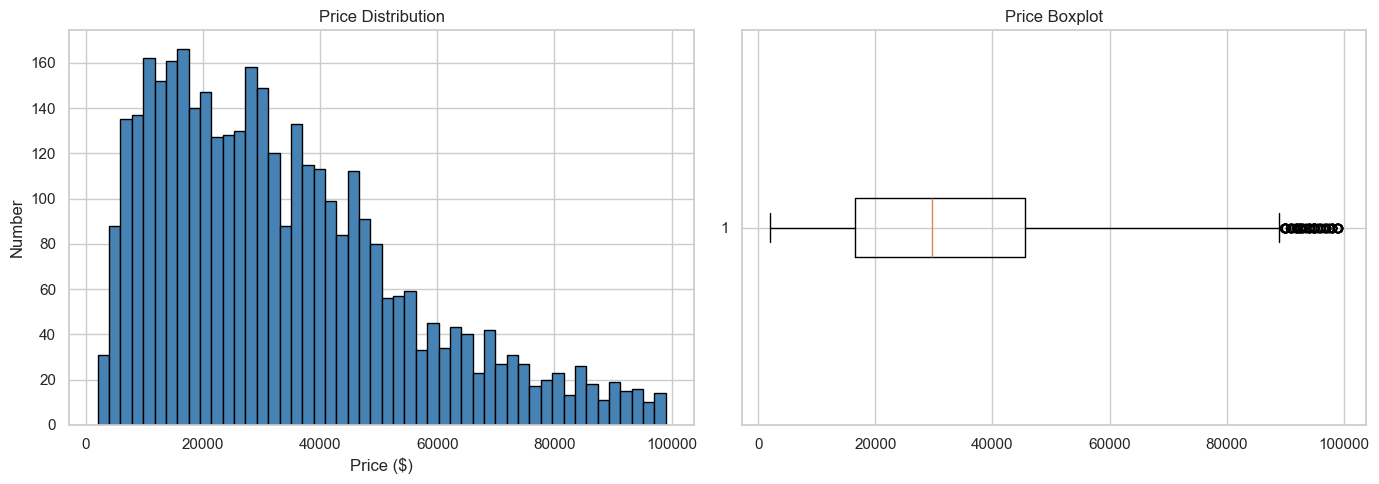

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Number')

axes[1].boxplot(df['price'], vert=False)
axes[1].set_title('Price Boxplot')

plt.tight_layout()
plt.savefig('reports/01_price_distribution.png', dpi=450)
plt.show()

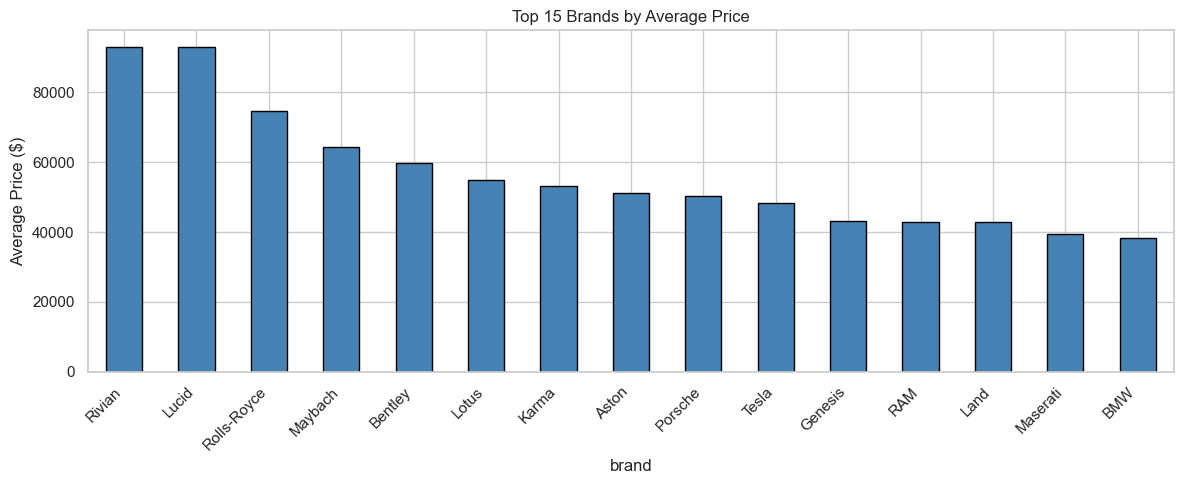

In [25]:
top_brands = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
top_brands.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Brands by Average Price')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('reports/02_brand_price.png', dpi=450)
plt.show()

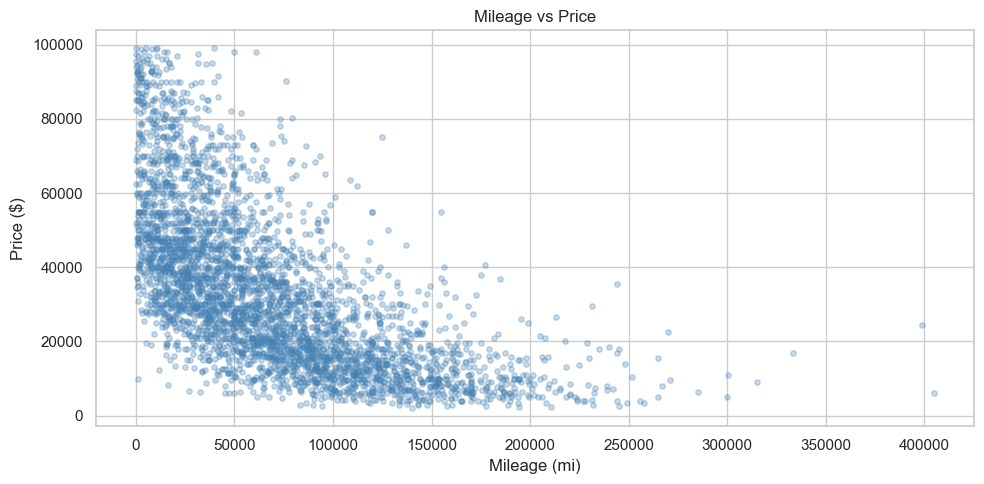

In [26]:
plt.figure(figsize=(10, 5))
plt.scatter(df['milage'], df['price'], alpha=0.3, color='steelblue', s=15)
plt.title('Mileage vs Price')
plt.xlabel('Mileage (mi)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('reports/03_mileage_vs_price.png', dpi=450)
plt.show()

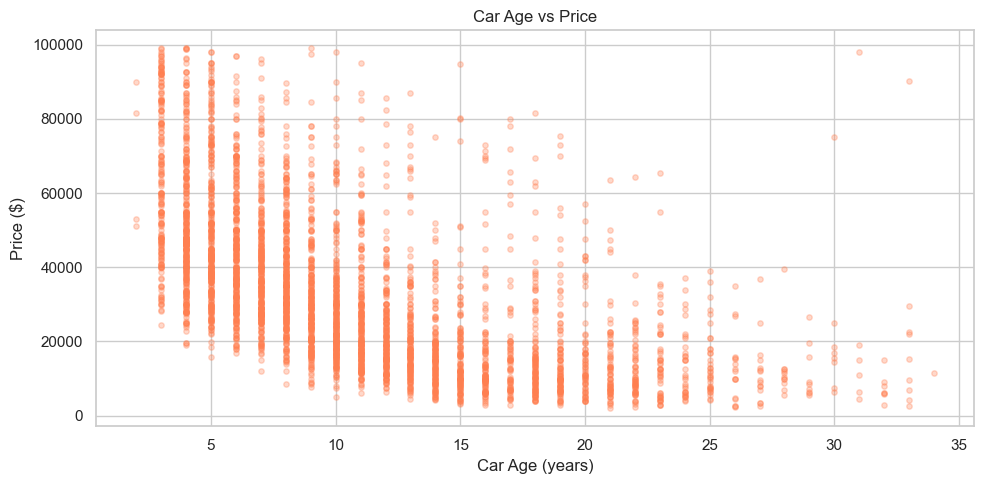

In [27]:
plt.figure(figsize=(10, 5))
plt.scatter(df['car_age'], df['price'], alpha=0.3, color='coral', s=15)
plt.title('Car Age vs Price')
plt.xlabel('Car Age (years)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('reports/04_age_vs_price.png', dpi=450)
plt.show()

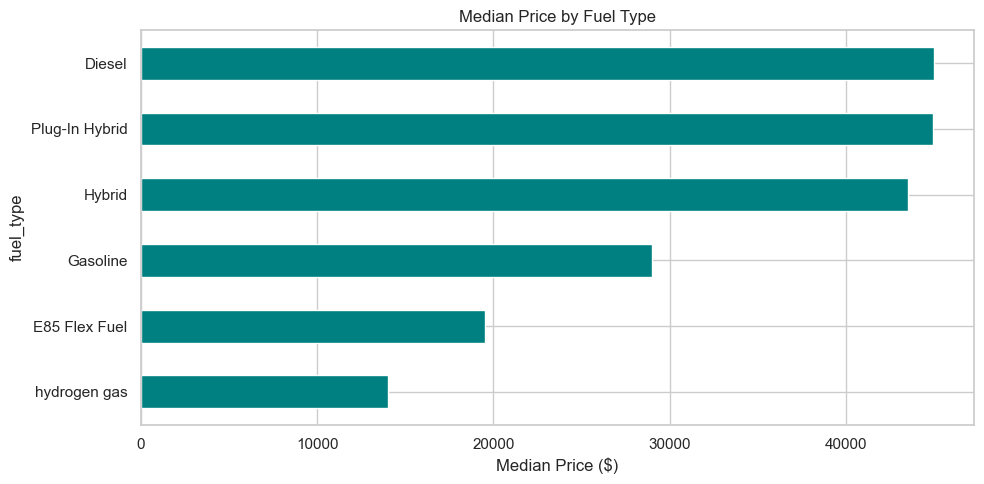

In [28]:
plt.figure(figsize=(10, 5))
df.groupby('fuel_type')['price'].median().sort_values().plot(
    kind='barh', color='teal', edgecolor='white')
plt.title('Median Price by Fuel Type')
plt.xlabel('Median Price ($)')
plt.tight_layout()
plt.savefig('reports/05_fuel_price.png', dpi=150)
plt.show()

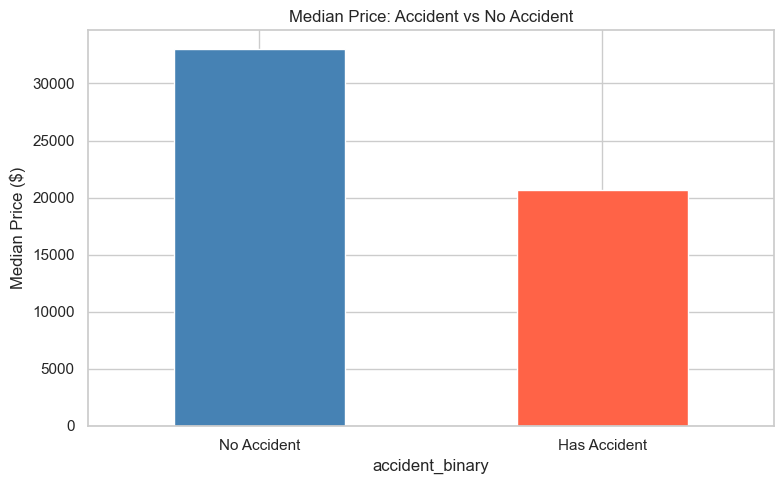

In [29]:
plt.figure(figsize=(8, 5))
df.groupby('accident_binary')['price'].median().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
plt.xticks([0, 1], ['No Accident', 'Has Accident'], rotation=0)
plt.title('Median Price: Accident vs No Accident')
plt.ylabel('Median Price ($)')
plt.tight_layout()
plt.savefig('reports/06_accident_price.png', dpi=450)
plt.show()

In [30]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'car_age', 'accident_binary', 'clean_title_binary',
       'brand_enc', 'fuel_type_enc', 'transmission_enc', 'ext_col_enc',
       'int_col_enc'],
      dtype='object')

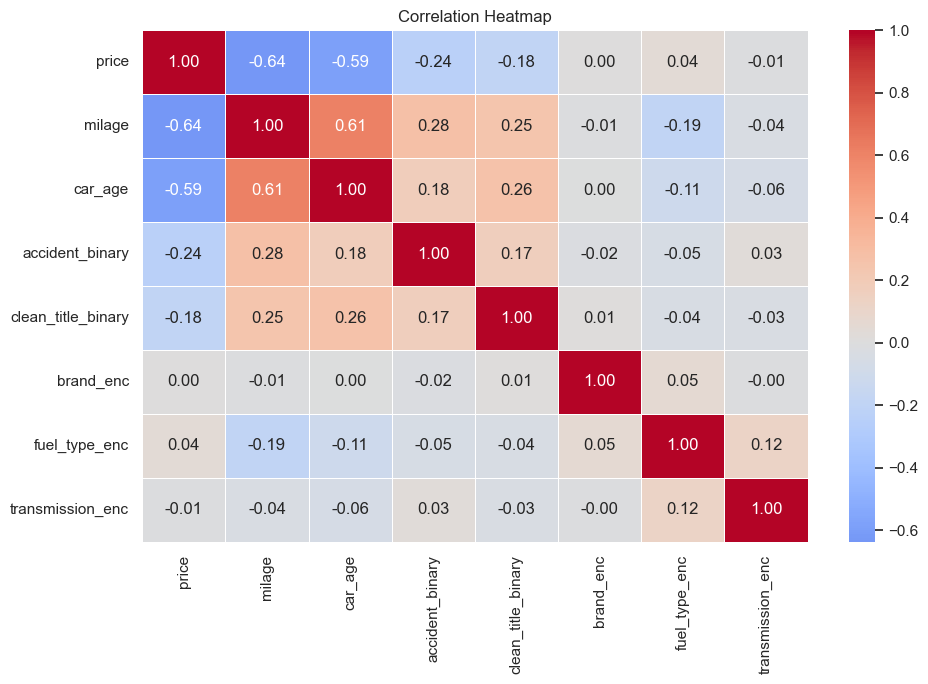

In [31]:
num_cols = ['price', 'milage', 'car_age', 'accident_binary',
            'clean_title_binary', 'brand_enc', 'fuel_type_enc', 'transmission_enc']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('reports/07_correlation_heatmap.png', dpi=450)
plt.show()

---

### Cell 2: Define X and y
### Only the features we selected from EDA

In [32]:
features = ['milage', 'car_age','accident_binary', 'clean_title_binary','brand_enc','fuel_type_enc','transmission_enc']

x = df[features]
y= df['price']

print(f'x shape: {x.shape}')
print(f"y range: ${y.min():,.0f} — ${y.max():,.0f}")

x shape: (3765, 7)
y range: $2,000 — $99,000


In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

print(f'Train size: {x_train.shape[0]} | Test size: {x_test.shape[0]}')

Train size: 3012 | Test size: 753


---

In [34]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),
    'SVR':               SVR(kernel='rbf', C=100, epsilon=0.1),
}

final_results = {}

- ### Linear Regression

In [35]:
lr_model = models['Linear Regression']
lr_model.fit(x_train_sc, y_train)

lr_preds = lr_model.predict(x_test_sc)

final_results['Linear Regression'] = {
    'R²':  round(r2_score(y_test, lr_preds), 4),
    'MAE': round(mean_absolute_error(y_test, lr_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, lr_preds)), 2)
}

print("✓ Linear Regression model was trained and evaluated.")


✓ Linear Regression model was trained and evaluated.


- ### Ridge Regression

In [36]:
ridge_model = models['Ridge']
ridge_model.fit(x_train_sc, y_train)

ridge_preds = ridge_model.predict(x_test_sc)

final_results['Ridge'] = {
    'R²':  round(r2_score(y_test, ridge_preds), 4),
    'MAE': round(mean_absolute_error(y_test, ridge_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, ridge_preds)), 2)
}
print("✓ Ridge Regression model was successfully trained.")

✓ Ridge Regression model was successfully trained.


- ### Lasso Regression

In [37]:
lasso_model = models['Lasso']
lasso_model.fit(x_train_sc, y_train)

lasso_preds = lasso_model.predict(x_test_sc)

final_results['Lasso'] = {
    'R²':  round(r2_score(y_test, lasso_preds), 4),
    'MAE': round(mean_absolute_error(y_test, lasso_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, lasso_preds)), 2)
}
print("✓ Lasso Regression model was successfully trained.")

✓ Lasso Regression model was successfully trained.


- ### KNN Regressor

In [38]:
knn_model = models['KNN']
knn_model.fit(x_train_sc, y_train)

knn_preds = knn_model.predict(x_test_sc)

final_results['KNN'] = {
    'R²':  round(r2_score(y_test, knn_preds), 4),
    'MAE': round(mean_absolute_error(y_test, knn_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, knn_preds)), 2)
}
print("✓ KNN Regressor model was successfully trained.")


✓ KNN Regressor model was successfully trained.


- ### Decision Tree Regressor

In [39]:
dt_model = models['Decision Tree']
dt_model.fit(x_train_sc, y_train)

dt_preds = dt_model.predict(x_test_sc)

final_results['Decision Tree'] = {
    'R²':  round(r2_score(y_test, dt_preds), 4),
    'MAE': round(mean_absolute_error(y_test, dt_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, dt_preds)), 2)
}
print("✓ Decision Tree model was successfully trained.")

✓ Decision Tree model was successfully trained.


- ### SVR

In [40]:
svr_model = models['SVR']
svr_model.fit(x_train_sc, y_train)

svr_preds = svr_model.predict(x_test_sc)

final_results['SVR'] = {
    'R²':  round(r2_score(y_test, svr_preds), 4),
    'MAE': round(mean_absolute_error(y_test, svr_preds), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, svr_preds)), 2)
}
print("✓ SVR model was successfully trained.")

✓ SVR model was successfully trained.


In [41]:
results_df = pd.DataFrame(final_results).T.sort_values('R²', ascending=False)
print("=================== Regression Models Comparison Table =================== \n")
print(results_df)

=================== Regression Models Comparison Table =================== 

                       R²       MAE      RMSE
KNN                0.5657  10096.73  13759.81
Decision Tree      0.5476  10526.98  14043.80
Linear Regression  0.4633  11768.75  15296.74
Ridge              0.4633  11768.47  15296.47
Lasso              0.4633  11768.54  15296.47
SVR                0.3607  11961.51  16694.21


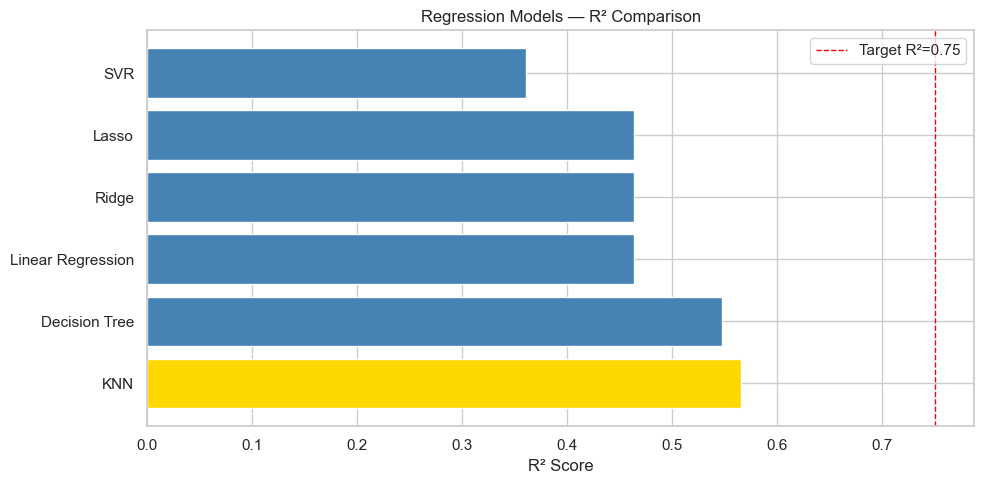

In [42]:
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
plt.barh(results_df.index, results_df['R²'], color=colors, edgecolor='white')
plt.axvline(x=0.75, color='red', linestyle='--', linewidth=1, label='Target R²=0.75')
plt.title('Regression Models — R² Comparison')
plt.xlabel('R² Score')
plt.legend()
plt.tight_layout()
plt.savefig('reports/08_regression_r2.png', dpi=150)
plt.show()

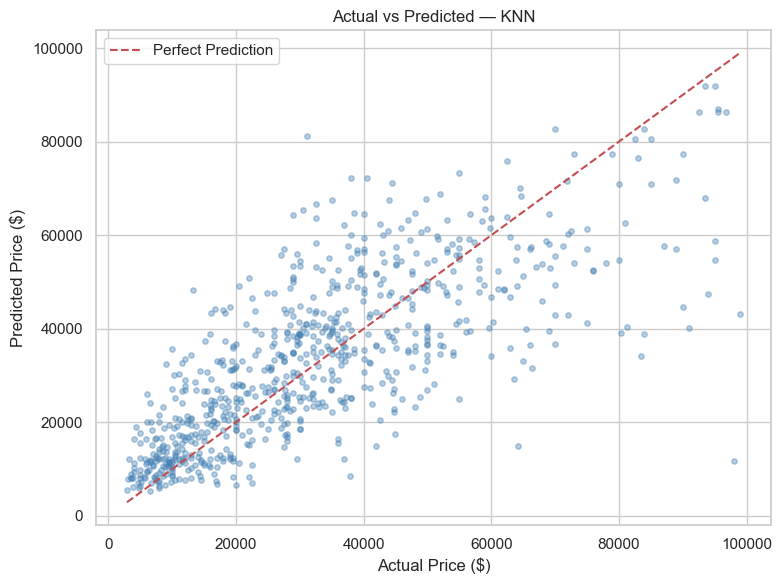

In [43]:
best_name = results_df.index[0]
best_model = models[best_name]
best_preds = best_model.predict(x_test_sc)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.4, s=15, color='steelblue')

# خط ایده‌آل: پیش‌بینی = واقعیت
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')

plt.title(f'Actual vs Predicted — {best_name}')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/09_actual_vs_predicted.png', dpi=450)
plt.show()

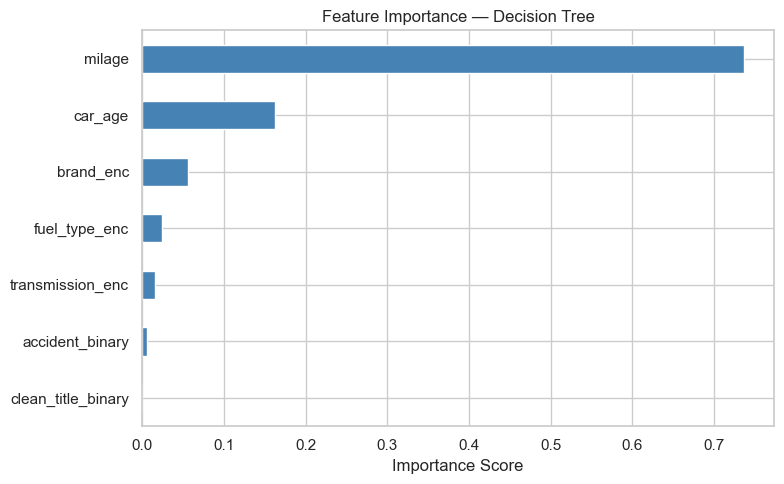

In [44]:
dt_model = models['Decision Tree']
importances = pd.Series(dt_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('reports/10_feature_importance.png', dpi=450)
plt.show()

In [45]:
joblib.dump(best_model, 'models/best_regression_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print(f"✓ Best model saved: {best_name}")
print(f"✓ R²: {results_df.loc[best_name, 'R²']}")
print(f"✓ MAE: ${results_df.loc[best_name, 'MAE']:,.0f}")

✓ Best model saved: KNN
✓ R²: 0.5657
✓ MAE: $10,097


---

In [46]:
df['price_category'] = pd.qcut(
    df['price'], q=3, labels=['Budget', 'Mid-Range', 'Premium']
)

print(df['price_category'].value_counts())
print(df['price_category'].value_counts(normalize=True).round(3))

price_category
Budget       1255
Mid-Range    1255
Premium      1255
Name: count, dtype: int64
price_category
Budget       0.333
Mid-Range    0.333
Premium      0.333
Name: proportion, dtype: float64


In [47]:
x = df[features]
y_cls = df['price_category']

x_train, x_test, y_train_cls, y_test_cls = train_test_split(x, y_cls, test_size=0.2, random_state=42)
x_train_sc = scaler.fit_transform(x_train)
x_tets_sc = scaler.transform(x_test)

print(f"Train: {x_train.shape[0]} | Test: {x_test.shape[0]}")

Train: 3012 | Test: 753


In [48]:
models_cls = {
    'KNN':          KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'SVM':          SVC(kernel='rbf', C=10, probability=True, random_state=42),
    'AdaBoost':     AdaBoostClassifier(n_estimators=100, random_state=42),
    'OvR (LR)':     OneVsRestClassifier(
                        DecisionTreeClassifier(max_depth=4, random_state=42)),
}

results_cls = {}

* ### KNN

In [49]:
knn_model_cls = models_cls['KNN']

knn_model_cls.fit(x_train_sc, y_train_cls)
preds_cls = knn_model_cls.predict(x_tets_sc)

reports_knn_cls = classification_report(y_test_cls, preds_cls, output_dict=True)
results_cls['KNN'] = {
    'Accuracy':   round(reports_knn_cls['accuracy'], 4),
    'F1 (macro)': round(reports_knn_cls['macro avg']['f1-score'], 4),
}

print("✓ KNN model was successfully trained and evaluated.")

✓ KNN model was successfully trained and evaluated.


* ### Decision Tree

In [50]:
dt_model_cls = models_cls['Decision Tree']

dt_model_cls.fit(x_train_sc, y_train_cls)
preds_dt_cls = dt_model_cls.predict(x_tets_sc)

report_dt_cls = classification_report(y_test_cls, preds_dt_cls, output_dict=True)
results_cls['Decision Tree'] = {
    'Accuracy':   round(report_dt_cls['accuracy'], 4),
    'F1 (macro)': round(report_dt_cls['macro avg']['f1-score'], 4),
}
print("✓ Decision Tree model was successfully trained and evaluated.")

✓ Decision Tree model was successfully trained and evaluated.


* ### SVM

In [51]:
svm_model_cls = models_cls['SVM']

svm_model_cls.fit(x_train_sc, y_train_cls)
preds_svm_cls = svm_model_cls.predict(x_tets_sc)

report = classification_report(y_test_cls, preds_svm_cls, output_dict=True)
results_cls['SVM'] = {
    'Accuracy':   round(report['accuracy'], 4),
    'F1 (macro)': round(report['macro avg']['f1-score'], 4),
}
print("✓ SVM model was successfully trained and evaluated.")

✓ SVM model was successfully trained and evaluated.


- ### AdaBoost

In [52]:
ab_model_cls = models_cls['AdaBoost']

ab_model_cls.fit(x_train_sc, y_train_cls)
preds_ab_cls = ab_model_cls.predict(x_tets_sc)

report = classification_report(y_test_cls, preds_ab_cls, output_dict=True)
results_cls['AdaBoost'] = {
    'Accuracy':   round(report['accuracy'], 4),
    'F1 (macro)': round(report['macro avg']['f1-score'], 4),
}
print("✓ AdaBoost model was successfully trained and evaluated.")

✓ AdaBoost model was successfully trained and evaluated.


- ### OvR (LR)

In [53]:
ovr_model_cls = models_cls['OvR (LR)']

ovr_model_cls.fit(x_train_sc, y_train_cls)
preds_ovr_cls = ovr_model_cls.predict(x_tets_sc)

report = classification_report(y_test_cls, preds_ovr_cls, output_dict=True)
results_cls['OvR (LR)'] = {
    'Accuracy':   round(report['accuracy'], 4),
    'F1 (macro)': round(report['macro avg']['f1-score'], 4),
}
print("✓ OvR model was successfully trained and evaluated.")

✓ OvR model was successfully trained and evaluated.


In [54]:
results_cls_df = pd.DataFrame(results_cls).T.sort_values('Accuracy', ascending=False)
print(results_cls_df)

               Accuracy  F1 (macro)
KNN              0.6879      0.6837
Decision Tree    0.6693      0.6573
SVM              0.6653      0.6577
AdaBoost         0.6627      0.6589
OvR (LR)         0.6494      0.6354


In [55]:
best_cls_name = results_cls_df.index[0]
best_cls_model = models_cls[best_cls_name]
best_cls_preds = best_cls_model.predict(x_tets_sc)

print(f"Best Model: {best_cls_name}\n")
print(classification_report(y_test_cls, best_cls_preds,
                             target_names=['Budget', 'Mid-Range', 'Premium']))

Best Model: KNN

              precision    recall  f1-score   support

      Budget       0.77      0.84      0.80       263
   Mid-Range       0.58      0.56      0.57       254
     Premium       0.70      0.67      0.68       236

    accuracy                           0.69       753
   macro avg       0.68      0.69      0.68       753
weighted avg       0.68      0.69      0.69       753



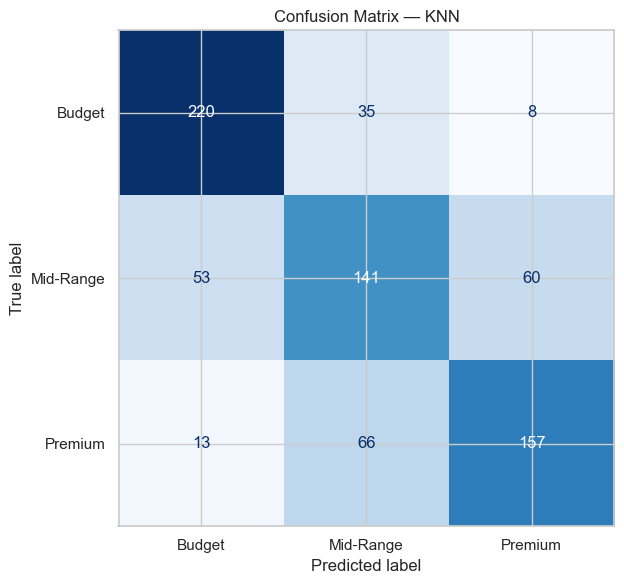

In [56]:
cm = confusion_matrix(y_test_cls, best_cls_preds,
                      labels=['Budget', 'Mid-Range', 'Premium'])

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Budget', 'Mid-Range', 'Premium'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_cls_name}')
plt.tight_layout()
plt.savefig('reports/11_confusion_matrix.png', dpi=450)
plt.show()

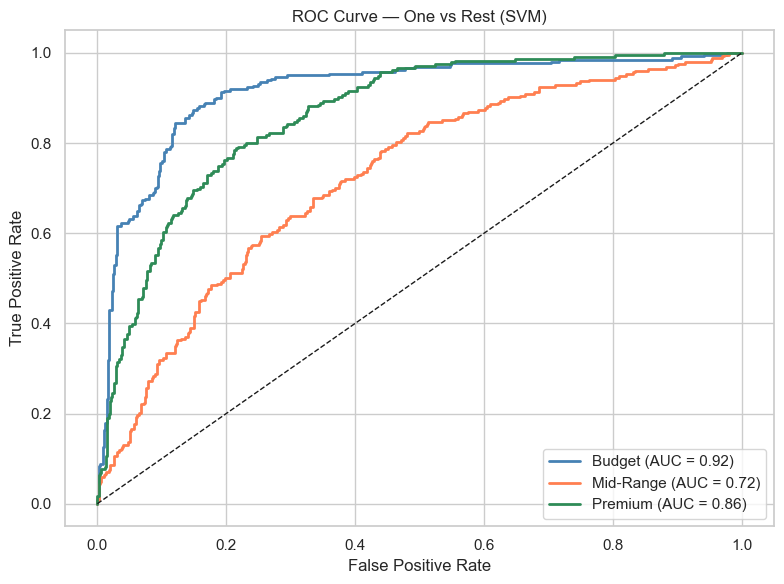

In [57]:
classes = ['Budget', 'Mid-Range', 'Premium']
y_test_bin = label_binarize(y_test_cls, classes=classes)
ovr_model = OneVsRestClassifier(
    SVC(kernel='rbf', C=10, probability=True, random_state=42)
)
ovr_model.fit(x_train_sc, y_train_cls)
y_score = ovr_model.predict_proba(x_tets_sc)

colors = ['steelblue', 'coral', 'seagreen']
plt.figure(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.title('ROC Curve — One vs Rest (SVM)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('reports/12_roc_curve.png', dpi=450)
plt.show()


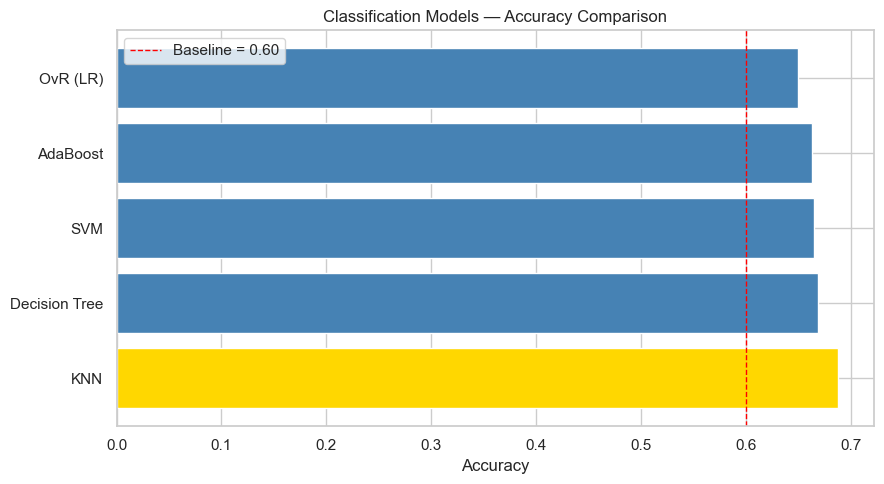

In [58]:
plt.figure(figsize=(9, 5))
colors_bar = ['gold' if i == 0 else 'steelblue'
              for i in range(len(results_cls_df))]
plt.barh(results_cls_df.index, results_cls_df['Accuracy'],
         color=colors_bar, edgecolor='white')
plt.axvline(x=0.60, color='red', linestyle='--',
            linewidth=1, label='Baseline = 0.60')
plt.title('Classification Models — Accuracy Comparison')
plt.xlabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('reports/13_classification_accuracy.png', dpi=150)
plt.show()

---